$$\Large\textbf{Amirreza Taheri - 4021300198003}$$

## <font color="red">**Note:**</font> Most codes are generated by chat-GPT or other LLM models.

## Homework 4
Hi everyone this is your fourth homework.

In this exercise, You will deal with **SVM**, **Decision Tree**.

You are free to discuss the problems and ways to approach them with your classmates, but be sure to not cheat. **Cheating will not be tolerated**.

# Support Vector Machine (SVM)

**A Support Vector Machine (SVM)** is a supervised machine learning algorithm that can be used for both classification and regression tasks. The primary objective of SVM is to find a hyperplane in an N-dimensional space (where N is the number of features) that distinctly classifies data points into different classes.

Here are some key concepts associated with SVM:

**Hyperplane:**

In a two-dimensional space, a hyperplane is a line that separates the data into different classes. In higher-dimensional spaces, it becomes a hyperplane.

**Support Vectors:**

Support Vectors are the data points that are closest to the decision boundary (hyperplane) and have a significant influence on its position. These points play a crucial role in defining the optimal hyperplane.

**Margin:**

The margin is the distance between the hyperplane and the nearest data point from either class. SVM aims to maximize this margin because a larger margin generally leads to better generalization performance.

**Kernel Trick:**

SVMs can handle non-linear decision boundaries by using a technique called the kernel trick.

**C Parameter:**

SVM has a parameter denoted as 'C,' which controls the trade-off between having a smooth decision boundary and classifying training points correctly. A smaller C value makes the decision boundary smoother, while a larger C value may lead to a more accurate classification of training points.

**Linear and Non-linear SVM:**

SVMs can be applied with linear and non-linear kernels. Linear SVM is suitable for linearly separable data, while non-linear SVM with kernels like Polynomial or Radial Basis Function (RBF) can handle more complex, non-linear relationships.

## <font color="red">**Question 1**</font>
In this question you are going to work with the iris dataset.
This dataset contains 3 classes, each of which has 50 members, and each class refers to a type of lily flower. Each element contains information about the length and width of the sepal and the length and width of the petal. Also, the data is labeled and its class is also known. You can refer to this [link](https://archive.ics.uci.edu/dataset/53/iris) for more details.


- First, separate the data using the linear kernel and express the correlation matrix of the recall, precision, and F1 score values.

To do this on the iris dataset, first take the first two features of all the data and then classify using the linear kernel. At the end, display the data graph with the labels of the corresponding classes as well as the separating lines of each class

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, svm
from sklearn.metrics import classification_report
from sklearn import datasets, svm
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
# Load the iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Select the first two features
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear SVM classifier
svm_classifier = svm.SVC(kernel='linear')

# Train the classifier
svm_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_classifier.predict(X_test)

# Calculate precision, recall, and F1 score
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)

# Calculate precision, recall, and F1-score for each class
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.88      0.78      0.82         9
           2       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



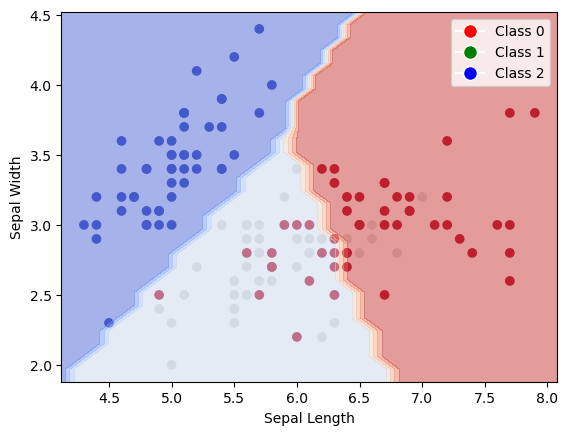

In [3]:
# Plot the data points with labels
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')

# Plot the separating lines of each class
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create a grid to evaluate the classifier
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_classifier.predict(xy).reshape(XX.shape)

# Plot the decision boundaries
ax.contourf(XX, YY, Z, alpha=0.5, cmap=plt.cm.coolwarm)

# Add legend for classes
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label='Class 0',
                              markerfacecolor='r', markersize=10),
                   plt.Line2D([0], [0], marker='o', color='w', label='Class 1',
                              markerfacecolor='g', markersize=10),
                   plt.Line2D([0], [0], marker='o', color='w', label='Class 2',
                              markerfacecolor='b', markersize=10)]
ax.legend(handles=legend_elements)

plt.show()

- Check the SVM method to classify the two features Petal Length and Petal Width.

In [4]:
# Load the iris dataset
iris = datasets.load_iris()
X = iris.data[:, 2:4]  # Select the features Petal Length and Petal Width
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear SVM classifier
svm_classifier = svm.SVC(kernel='linear')

# Train the classifier
svm_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_classifier.predict(X_test)

# Calculate precision, recall, and F1 score
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)

# Print the classification report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



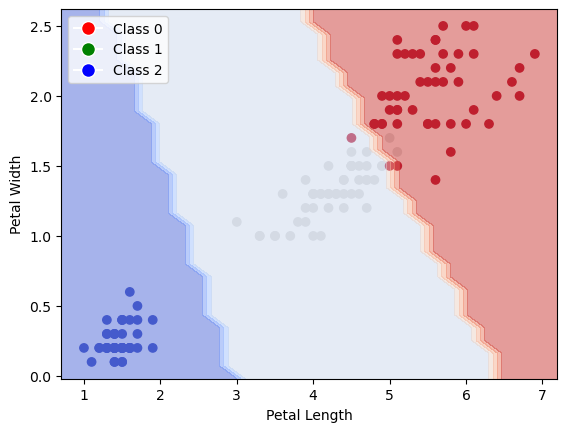

In [5]:
# Plot the data points with labels
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

# Plot the separating lines of each class
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create a grid to evaluate the classifier
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_classifier.predict(xy).reshape(XX.shape)

# Plot the decision boundaries
ax.contourf(XX, YY, Z, alpha=0.5, cmap=plt.cm.coolwarm)

# Add legend for classes
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label='Class 0',
                              markerfacecolor='r', markersize=10),
                   plt.Line2D([0], [0], marker='o', color='w', label='Class 1',
                              markerfacecolor='g', markersize=10),
                   plt.Line2D([0], [0], marker='o', color='w', label='Class 2',
                              markerfacecolor='b', markersize=10)]
ax.legend(handles=legend_elements)

plt.show()

- Research about polynomial, linear, and rbf kernels and state which datasets each one is suitable for classification. Apply the classification to the items in the previous section and analyze the results.

$$\textbf{Polynomial Kernel}$$

A polynomial kernel in Support Vector Machine (SVM) is a function that allows you to transform your original dataset into a higher dimensional space using a polynomial kernel function. It is usually used to find non-linear relationships in the data. In the polynomial kernel, the degree parameter determines the degree of the polynomial used for the transformation.

$$\textbf{Linear Kernel}$$

The linear kernel in Support Vector Machine (SVM) is a type of kernel that is used to transform a dataset into a higher dimensional space in a linear manner. It is often used when the data is linearly separable, which means you can classify the daya by a straight line or hyperplane.

$$\textbf{RBF Kernel}$$

The Radial Basis Function (RBF) kernel in Support Vector Machines (SVM) is a type of kernel for nonlinear classification. The RBF kernel uses a Gaussian function to calculate the similarity between each pair of data points to map them into a higher-dimensional space. It is defined as $K(x, x') = exp(-\gamma * ||x - x'||^2)$, where $\gamma$ is a parameter for controlling the smoothness of the decision boundary and the trade-off between the model's bias and variance.

The main difference between these three kernels lies in their ability to capture different types of patterns and relationships in the data. The linear kernel calculates the decision boundary as a straight line or hyperplane, the polynomial kernel calculates it as a curved line, and the RBF kernel calculates a non-linear flexible decision boundary.

<font color="green">**Answer:**</font>

$$\textbf{For the first two features}$$

In [6]:
# Load the iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Select the first two features
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
# Linear SVM
linear_svm = svm.SVC(kernel='linear')
linear_svm.fit(X_train, y_train)
linear_y_pred = linear_svm.predict(X_test)
linear_report = classification_report(y_test, linear_y_pred)
print("Linear SVM:")
print(linear_report)
print()


Linear SVM:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.88      0.78      0.82         9
           2       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30




In [8]:
# Polynomial SVM
poly_svm = svm.SVC(kernel='poly', degree=3)
poly_svm.fit(X_train, y_train)
poly_y_pred = poly_svm.predict(X_test)
poly_report = classification_report(y_test, poly_y_pred)
print("Polynomial SVM:")
print(poly_report)
print()


Polynomial SVM:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.70      0.78      0.74         9
           2       0.80      0.73      0.76        11

    accuracy                           0.83        30
   macro avg       0.83      0.84      0.83        30
weighted avg       0.84      0.83      0.83        30




In [9]:
# RBF SVM
rbf_svm = svm.SVC(kernel='rbf')
rbf_svm.fit(X_train, y_train)
rbf_y_pred = rbf_svm.predict(X_test)
rbf_report = classification_report(y_test, rbf_y_pred)
print("RBF SVM:")
print(rbf_report)
print()

RBF SVM:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.88      0.78      0.82         9
           2       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30




$$\textbf{Analyze}$$

RBF has reached the same result as linear, which means that linear classification is the best for this data. While polynomial kernel has reached to lower score which inteprets that, it is maybe overfitting on the data, and poly kernel is too complex for classifying this dataand it's better to use simpler kernel such as linear kernel for this data.

- Research regularization, Gamma hyperparameters. Change each of the hyperparameters 3 times and repeat the classification for each. Analyze the effect of each hyperparameter on the classification.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, svm
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Load the iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Select the first two features
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a list of regularization parameter (C) values to try
C_values = [0.1, 0.5, 1, 5, 10]

# Define a list of gamma values to try
gamma_values = [0.1, 0.5, 1, 5, 10]


In [11]:
results = []

# Iterate over different C values
for C in C_values:
    # Iterate over different gamma values
    for gamma in gamma_values:
        print(f"Regularization parameter (C): {C}, Gamma: {gamma}")
        
        # Create an SVM classifier with the current C and gamma values
        svm_classifier = svm.SVC(kernel='rbf', C=C, gamma=gamma)
        
        # Train the classifier
        svm_classifier.fit(X_train, y_train)
        
        # Make predictions on the test set
        y_pred = svm_classifier.predict(X_test)
        
        # Calculate the accuracy
        score = svm_classifier.score(X_test, y_test)
        
        # Generate a classification report
        report = classification_report(y_test, y_pred)
        print(report)
        print()
        
        # Append the results to the list
        results.append((C, gamma, round(score, 3)))

Regularization parameter (C): 0.1, Gamma: 0.1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.47      1.00      0.64         9
           2       1.00      0.09      0.17        11

    accuracy                           0.67        30
   macro avg       0.82      0.70      0.60        30
weighted avg       0.84      0.67      0.59        30


Regularization parameter (C): 0.1, Gamma: 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.70      0.78      0.74         9
           2       0.80      0.73      0.76        11

    accuracy                           0.83        30
   macro avg       0.83      0.84      0.83        30
weighted avg       0.84      0.83      0.83        30


Regularization parameter (C): 0.1, Gamma: 1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00  

/root/miniconda3/envs/ML-TeIAS/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/miniconda3/envs/ML-TeIAS/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/miniconda3/envs/ML-TeIAS/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/m

In [12]:
# Sort the results by score in descending order
results.sort(key=lambda x: x[2], reverse=True)

# Report the best hyperparameter combinations ranked by score
print("Best Hyperparameter Combinations (Ranked by Score):")
for i, (C, gamma, score) in enumerate(results):
    print(f"Rank {i+1}\t: Regularization parameter (C): {C},\t Gamma: {gamma},\t Score: {score}")

Best Hyperparameter Combinations (Ranked by Score):
Rank 1	: Regularization parameter (C): 5,	 Gamma: 1,	 Score: 0.933
Rank 2	: Regularization parameter (C): 0.1,	 Gamma: 1,	 Score: 0.9
Rank 3	: Regularization parameter (C): 0.5,	 Gamma: 0.5,	 Score: 0.9
Rank 4	: Regularization parameter (C): 0.5,	 Gamma: 1,	 Score: 0.9
Rank 5	: Regularization parameter (C): 0.5,	 Gamma: 5,	 Score: 0.9
Rank 6	: Regularization parameter (C): 0.5,	 Gamma: 10,	 Score: 0.9
Rank 7	: Regularization parameter (C): 1,	 Gamma: 0.1,	 Score: 0.9
Rank 8	: Regularization parameter (C): 1,	 Gamma: 0.5,	 Score: 0.9
Rank 9	: Regularization parameter (C): 1,	 Gamma: 1,	 Score: 0.9
Rank 10	: Regularization parameter (C): 5,	 Gamma: 0.1,	 Score: 0.9
Rank 11	: Regularization parameter (C): 5,	 Gamma: 0.5,	 Score: 0.9
Rank 12	: Regularization parameter (C): 10,	 Gamma: 0.5,	 Score: 0.9
Rank 13	: Regularization parameter (C): 1,	 Gamma: 5,	 Score: 0.867
Rank 14	: Regularization parameter (C): 5,	 Gamma: 10,	 Score: 0.867
Ra

The effect of each hyperparameter is observable in the previous cell's ranking. However it seems there is no recognizable pattern in the combinations.

- Calculate the best parameters of the previous part with the help of grid search and repeat the classification for the kernels you checked in the third part and analyze the results.

In [13]:
# Load the iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Select the first two features
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid for grid search
param_grid = {
    'C': [0.01, 0.1, 0.5, 1, 2, 5,10],
    'gamma': [0.01, 0.1, 0.5, 1, 2, 5,10],
}

# Create an SVM classifier
svm_classifier = svm.SVC()

# Perform grid search with cross-validation
grid_search = GridSearchCV(svm_classifier, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'C': 0.5, 'gamma': 1}


In [14]:
# Kernel: linear
print("Kernel: linear")
    
# Create an SVM classifier with the best hyperparameters
svm_classifier = svm.SVC(kernel='linear', **best_params)

# Train the classifier
svm_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_classifier.predict(X_test)

# Generate a classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)
print()

Kernel: linear
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.88      0.78      0.82         9
           2       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30




In [15]:
# Kernel: poly
print("Kernel: poly")
    
# Create an SVM classifier with the best hyperparameters
svm_classifier = svm.SVC(kernel='poly', **best_params)

# Train the classifier
svm_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_classifier.predict(X_test)

# Generate a classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)
print()

Kernel: poly
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.64      0.78      0.70         9
           2       0.78      0.64      0.70        11

    accuracy                           0.80        30
   macro avg       0.80      0.80      0.80        30
weighted avg       0.81      0.80      0.80        30




In [16]:
# Kernel: RBF
print("Kernel: RBF")
    
# Create an SVM classifier with the best hyperparameters
svm_classifier = svm.SVC(kernel='rbf', **best_params)

# Train the classifier
svm_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_classifier.predict(X_test)

# Generate a classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)
print()

Kernel: RBF
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.88      0.78      0.82         9
           2       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30




$$\textbf{Analyze}$$


RBF has reached the same result as linear, which means that linear classification is the best for this data. While polynomial kernel has reached to lower score which inteprets that, it is maybe overfitting on the data, and poly kernel is too complex for classifying this dataand it's better to use simpler kernel such as linear kernel for this data.

# SVM Regression

**Support Vector Machine (SVM) regression**, also known as Support Vector Regression (SVR), is a type of machine learning algorithm that is used for regression tasks. While traditional SVMs are designed for classification, SVR extends the concept to predict continuous values, making it suitable for regression problems where the goal is to predict a numeric output rather than class labels. The primary idea behind SVM regression is to find a hyperplane that best represents the relationship between the input features and the continuous target variable


## <font color="red">**Question 2**</font>

In this question, we want to solve an SVR problem with the help of the attached data set of people's income based on their job position. This data set contains three columns, in the first column their job position is described, in the second column is the work rank, and in the third column is the amount of income. In this question, with the help of three kernels **rbf, linear and polynomial**, predict the income of people and display the estimated and actual values in a graph.

Import **Data.csv** as a dataset for this question.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR

In [18]:
# Load the dataset
data = pd.read_csv("Data.csv")

In [19]:
print(data)

            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000


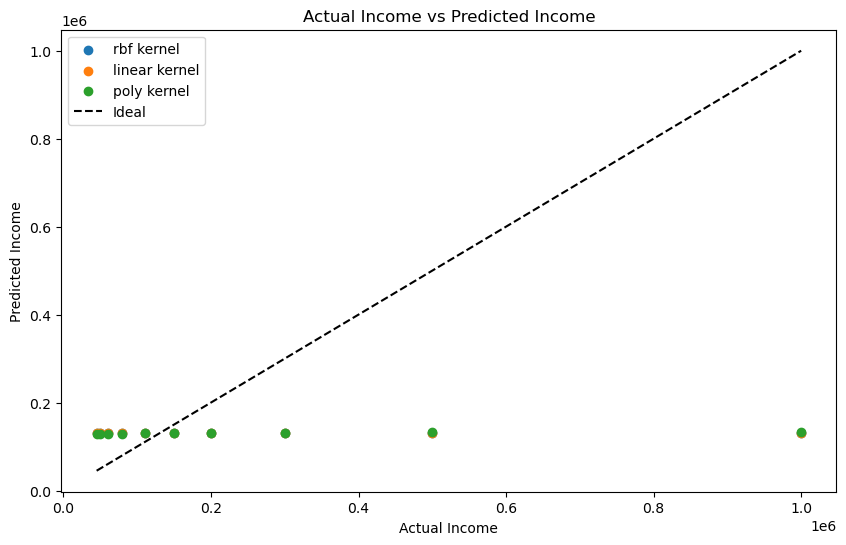

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# Load the dataset
data = pd.read_csv("Data.csv")
X = data.iloc[:, 1:2].values
y = data.iloc[:, 2].values

# Create SVR models with different kernels
kernels = ['rbf', 'linear', 'poly']
svr_models = []

for kernel in kernels:
    # Create SVR model
    svr = SVR(kernel=kernel)
    
    # Fit the model
    svr.fit(X, y)
    
    # Add the model to the list
    svr_models.append(svr)

# Plot actual income vs predicted income
plt.figure(figsize=(10, 6))
for i, kernel in enumerate(kernels):
    svr = svr_models[i]
    y_pred = svr.predict(X)
    plt.scatter(y, y_pred, label=f"{kernel} kernel")

plt.plot([min(y), max(y)], [min(y), max(y)], color='black', linestyle='--', label='Ideal')
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Actual Income vs Predicted Income")
plt.legend()
plt.show()

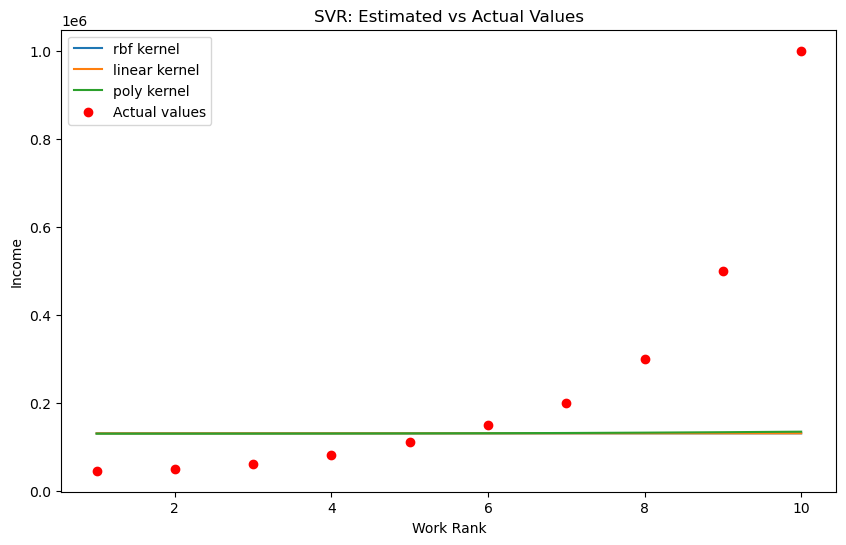

In [21]:
# Plot the estimated and actual values
plt.figure(figsize=(10, 6))
for i, kernel in enumerate(kernels):
    svr = svr_models[i]
    y_pred = svr.predict(X)
    plt.plot(X, y_pred, label=f"{kernel} kernel")
    
plt.scatter(X, y, color='red', label='Actual values')
plt.xlabel("Work Rank")
plt.ylabel("Income")
plt.title("SVR: Estimated vs Actual Values")
plt.legend()
plt.show()

In [22]:
from sklearn.metrics import mean_squared_error

# Create an empty list to store the MSE values
mse_values = []

# Calculate MSE for each kernel
for i, kernel in enumerate(kernels):
    svr = svr_models[i]
    y_pred = svr.predict(X)
    mse = mean_squared_error(y, y_pred)
    mse_values.append(mse)

# Create a dictionary to store the MSE values with their corresponding kernel
mse_dict = dict(zip(kernels, mse_values))

# Sort the MSE values in ascending order
sorted_mse = sorted(mse_dict.items(), key=lambda x: x[1])

# Rank the kernels by MSE
ranked_kernels = [x[0] for x in sorted_mse]

# Print the ranked kernels
print("Ranked Kernels by MSE:")
for i, kernel in enumerate(ranked_kernels):
    print(f"Rank {i+1}: {kernel} kernel (MSE: {mse_dict[kernel]})")

Ranked Kernels by MSE:
Rank 1: poly kernel (MSE: 93988469701.88322)
Rank 2: linear kernel (MSE: 94909142656.25)
Rank 3: rbf kernel (MSE: 94941391135.1919)


There is no significance difference between the kernels. They are all equally bad.

# Decision Tree

A **Decision Tree** is a popular supervised machine learning algorithm used for both classification and regression tasks. It works by recursively partitioning the data into subsets based on the values of input features, ultimately assigning a label or predicting a target variable for each observation. Decision Trees have several advantages, including simplicity, interpretability, and the ability to handle both numerical and categorical data. However, they can be sensitive to noise and outliers.

## <font color="red">**Question 3**</font>

- What is pruning in the context of Decision Trees? Why is it done, and how does it contribute to preventing overfitting?


### <font color="green">**Answer:**</font>

Pruning is a technique used in decision trees to make them more effective and genralizable. It's like trimming or cutting off some parts of the tree to to avoid it from becoming too complicated. This is important because when a decision tree becomes too complicated, it can become too focused on the training data and not perform well with the unseen new data.

Pruning helps to prevent this by simplifying the decision tree. It removes unnecessary parts that might be capturing noises in the training data. By doing this, the decision tree becomes more balanced and can make better predictions with new data.

There are two types of pruning: pre-pruning and post-pruning.

Pre-pruning involves setting rules or limits during the making the tree. For example, we can set limit on how deep the tree can grow or how many samples are needed to split a node.

Post-pruning, on the other hand, involves first building the full tree and then removing parts that don't don't have prediction power.


- How does the application of Decision Trees differ in regression tasks compared to classification tasks? What is predicted at the leaf nodes in regression?


### <font color="green">**Answer:**</font>

In classification tasks, Decision Trees help to predict the class or category of an input, such as determining if an email is spam or not.

On the other hand, in regression tasks, Decision Trees are used to estimate or forecast a numerical value. For example, instead of classifying an email as spam or not, we may use regression to predict the probability of an email being spam based on various features.

In regression, the leaf nodes of the Decision Tree do not represent classes like in classification. Instead, they represent a specific value or a range of values that are used to forecast the numerical outcome. For example, if we are predicting the price of a house, the leaf nodes might represent different price ranges or specific price values.

In summary, the main difference is the type of output they produce. Regression tasks estimate continuous numerical values, and the leaf nodes in regression Decision Trees predict specific values or value ranges.

## <font color="red">**Question 4**</font>

In this question, you will work with the **Diabetes.csv** dataset to classify diabetics and non-diabetics.

- First, divide the data into the most and test data with a ratio of 7 to 3 and apply a decision tree on them. Report and compare accuracy for test and training data.

In [23]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, make_scorer
from sklearn.model_selection import train_test_split

In [24]:
from sklearn.tree import export_graphviz
import six
import sys
sys.modules['sklearn.externals.six'] = six
from sklearn.externals.six import StringIO
from IPython.display import Image
import pydotplus

In [25]:
# Load the dataset
diabetes_df = pd.read_csv('Diabetes.csv')

In [26]:
diabetes_df.head()

,pregnant,glucose,BP,skin,insulin,BMI,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
# Get unique values and their repeat count for each column
for column in diabetes_df.columns:
    unique_values = diabetes_df[column].unique()
    repeat_count = diabetes_df[column].value_counts()
    print("Column:", column)
    print("Unique Values:", unique_values)
    print("Repeat Count:")
    print(repeat_count)
    print()


Column: pregnant
Unique Values: [ 6  1  8  0  5  3 10  2  4  7  9 11 13 15 17 12 14]
Repeat Count:
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
15      1
17      1
Name: pregnant, dtype: int64

Column: glucose
Unique Values: [148  85 183  89 137 116  78 115 197 125 110 168 139 189 166 100 118 107
 103 126  99 196 119 143 147  97 145 117 109 158  88  92 122 138 102  90
 111 180 133 106 171 159 146  71 105 101 176 150  73 187  84  44 141 114
  95 129  79   0  62 131 112 113  74  83 136  80 123  81 134 142 144  93
 163 151  96 155  76 160 124 162 132 120 173 170 128 108 154  57 156 153
 188 152 104  87  75 179 130 194 181 135 184 140 177 164  91 165  86 193
 191 161 167  77 182 157 178  61  98 127  82  72 172  94 175 195  68 186
 198 121  67 174 199  56 169 149  65 190]
Repeat Count:
99     17
100    17
111    14
129    14
125    14
       ..
191     1
177     1
44      1
62      1
190

In [28]:
# Check for null values in each column
null_counts = diabetes_df.isnull().sum()
print("Null Counts:")
print(null_counts)

Null Counts:
pregnant    0
glucose     0
BP          0
skin        0
insulin     0
BMI         0
pedigree    0
age         0
label       0
dtype: int64


In [29]:
import pandas as pd

# Load the dataset
diabetes_df = pd.read_csv('Diabetes.csv')

# Check for non-numerical values in each column
non_numeric_columns = []
for column in diabetes_df.columns:
    if not diabetes_df[column].apply(lambda x: isinstance(x, (int, float))).all():
        non_numeric_columns.append(column)

if len(non_numeric_columns) > 0:
    print("Non-Numerical Columns:")
    for column in non_numeric_columns:
        print(column)
else:
    print("No non-numerical columns found.")

No non-numerical columns found.


In [30]:
# Split the data into features (X) and target variable (y)
X = diabetes_df.drop('label', axis=1)
y = diabetes_df['label']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a decision tree classifier
clf = DecisionTreeClassifier()

# Train the classifier on the training data
clf.fit(X_train, y_train)

# Predict the target variable for training and test data
train_predictions = clf.predict(X_train)
test_predictions = clf.predict(X_test)

# Calculate accuracy for training and test data
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

# Print the accuracy
print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", round(test_accuracy, 4))

Training Accuracy: 1.0
Test Accuracy: 0.7056


- Display the decision tree you created using the available libraries.

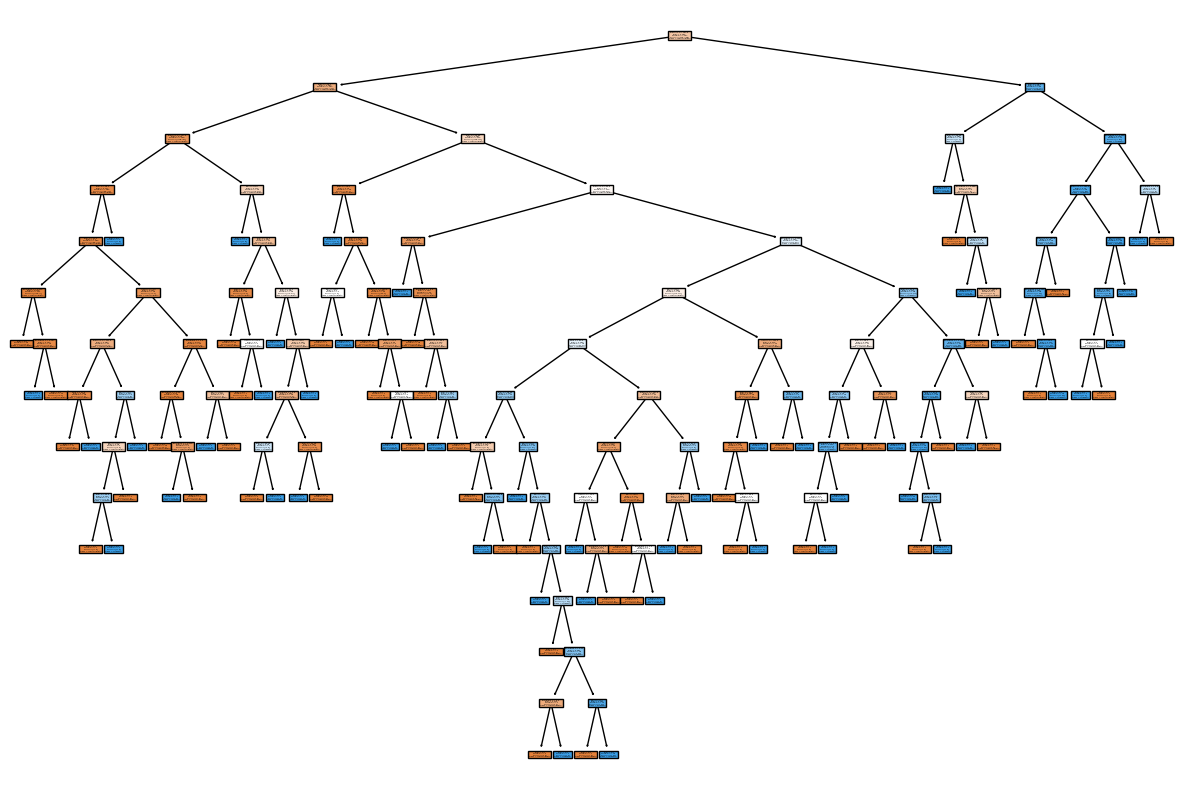

In [31]:
# Display the decision tree
plt.figure(figsize=(15, 10))
tree.plot_tree(clf, filled=True, feature_names=X.columns, class_names=['Non-Diabetic', 'Diabetic'])
plt.show()

- Now design a tree whose maximum depth = 2. Compare the accuracy values for the test and training data reported with the results obtained in the first part.

In [57]:
# Split the data into features (X) and target variable (y)
X = diabetes_df.drop('label', axis=1)
y = diabetes_df['label']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a decision tree classifier with max depth of 2
clf = DecisionTreeClassifier(max_depth=2)

# Train the classifier on the training data
clf.fit(X_train, y_train)

# Predict the target variable for training and test data
train_predictions = clf.predict(X_train)
test_predictions = clf.predict(X_test)

# Calculate accuracy for training and test data
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

# Print the accuracy for max depth = 2
print("Max Depth = 2")
print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Max Depth = 2
Training Accuracy: 0.7597765363128491
Test Accuracy: 0.7186147186147186


- Display the tree from the previous section and compare it with the results of section b in terms of interpretability.

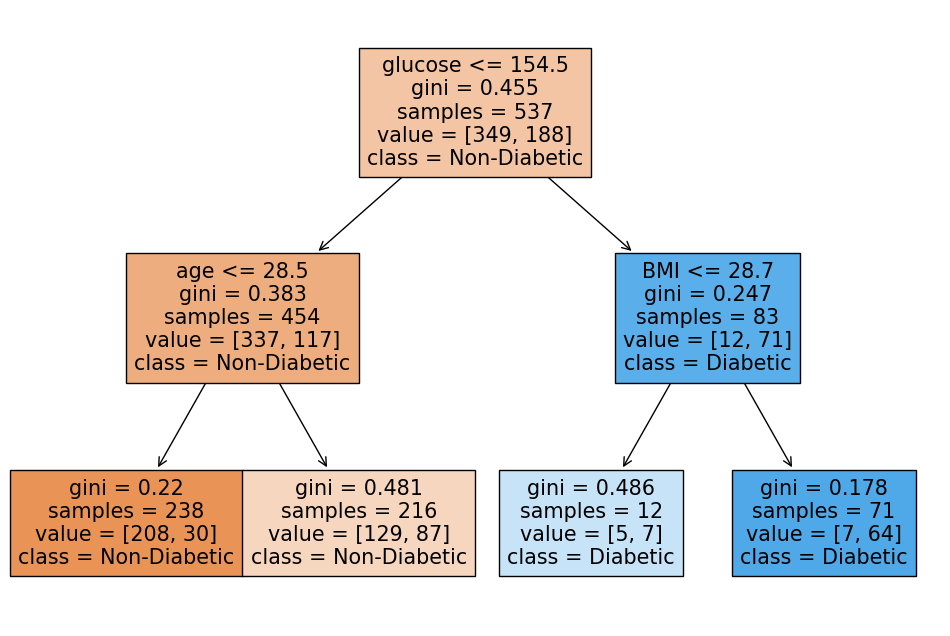

In [59]:
# Display the decision tree
plt.figure(figsize=(12, 8))
tree.plot_tree(clf, filled=True, feature_names=X.columns, class_names=['Non-Diabetic', 'Diabetic'])
plt.show()

$$\textbf{ Interpret}$$

* If Glucose is less than or equal to 154.50, go to the left branch.
* * If Age is less than or equal to 28.50, go to the left branch
* * * The predicted class label is 0.
* * If Age is greater than 28.50, go to the right branch.
* * * The predicted class label is 0



* If Glucose is greater than 154.50, go to the right branch.
* * If BMI is less than or equal to 28.70, go to the left branch
* * * The predicted class label is 1.
* * If BMI is greater than 28.70, go to the right branch.
* * * The predicted class label is 1

$$\textbf{Compare}$$

The results Shows that, the first desicion tree waas overfitting on the training data. It was giving a perfect fit on the training data while its genealizability and score on the test set was lower, compared to the secon model.\
On the other hand, the second model is fitting better on the test set, while fitting much worse on the training set which implies we have controlled the overfitting.


The tree graph of the second model is much more interpretable than the inital one. The initial tree had so much branches that we weren't even able to read the texts in each node.

### Go for Depth = 1 (Out of Curosity)

In [60]:
# Split the data into features (X) and target variable (y)
X = diabetes_df.drop('label', axis=1)
y = diabetes_df['label']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a decision tree classifier with max depth of 2
clf = DecisionTreeClassifier(max_depth=1)

# Train the classifier on the training data
clf.fit(X_train, y_train)

# Predict the target variable for training and test data
train_predictions = clf.predict(X_train)
test_predictions = clf.predict(X_test)

# Calculate accuracy for training and test data
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

# Print the accuracy for max depth = 1
print("Max Depth = 1")
print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Max Depth = 1
Training Accuracy: 0.7597765363128491
Test Accuracy: 0.7186147186147186


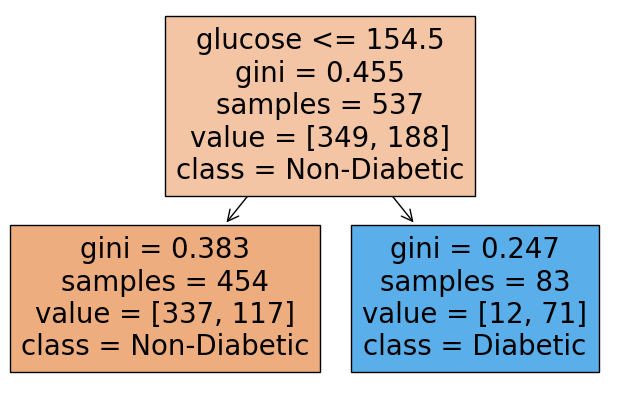

In [61]:
# Display the decision tree
plt.figure(figsize=(8, 5))
tree.plot_tree(clf, filled=True, feature_names=X.columns, class_names=['Non-Diabetic', 'Diabetic'])
plt.show()

In depth=1, we have the same result as dept=2, while the tree is even more interpretable than before.

$$\textbf{ Interpret}$$

* If Glucose is less than or equal to 154.50, the predicted class label is 0.

* If Glucose is greater than 154.50, the predicted class label is 1.

## <font color="red">**Question 5**</font>

In this problem, You deal with **OJ** dataset.

The orange juice (OJ) data set is about customer purchases for the Citrus Hill and Minute Maid brands of orange juice.

Target column is *Purchase*

In [36]:
from ISLP import load_data
oj = load_data('OJ')

In [37]:
oj['Store7'] = oj['Store7'].map({'Yes': 1, 'No': 0})
oj.head()

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,0,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,0,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,0,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,0,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,1,0.000000,0.000000,0.00,0


- Create a training set containing a random sample of 800 observations, and a test set containing the remaining observations.

In [38]:
# Create a training set with 800 random observations
train_set = oj.sample(n=800, random_state=42)

# Create a test set with the remaining observations
test_set = oj.drop(train_set.index)

# Checking the shape of the training and test sets
print("Training set shape:", train_set.shape)
print("Test set shape:", test_set.shape)


Training set shape: (800, 18)
Test set shape: (270, 18)


In [39]:
train_set.head()

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
644,CH,239,3,1.79,2.23,0.0,0.0,0,0,0.670149,2.23,1.79,0.44,0,0.000000,0.0,0.44,3
629,MM,260,2,1.86,2.18,0.0,0.7,0,0,0.456000,1.48,1.86,-0.38,0,0.321101,0.0,0.32,2
70,CH,274,4,1.99,2.09,0.0,0.4,0,0,0.718311,1.69,1.99,-0.30,0,0.191388,0.0,0.10,4
962,CH,227,1,1.69,1.69,0.0,0.0,0,0,0.600000,1.69,1.69,0.00,0,0.000000,0.0,0.00,1
787,CH,273,3,1.99,2.09,0.0,0.4,0,0,0.053687,1.69,1.99,-0.30,0,0.191388,0.0,0.10,3


In [40]:
oj.columns

Index(['Purchase', 'WeekofPurchase', 'StoreID', 'PriceCH', 'PriceMM', 'DiscCH',
       'DiscMM', 'SpecialCH', 'SpecialMM', 'LoyalCH', 'SalePriceMM',
       'SalePriceCH', 'PriceDiff', 'Store7', 'PctDiscMM', 'PctDiscCH',
       'ListPriceDiff', 'STORE'],
      dtype='object')

There is no variable $\large\textbf{Buy}$ in the dataset!!!

- Fit a tree to the training data, with Purchase as the response and the other variables except for $\large\textbf{Buy}$ as predictors. Use the summary() function to produce summary statistics about the tree, and describe the results obtained. What is the training error rate?

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

$$\text{Make a summary function, since there is no such a function for trees in Python.}$$

In [52]:
def tree_summary(tree, feature_names):
    # Get the variables used in tree construction
    used_features = [feature_names[i] for i in tree.tree_.feature if i != -2]

    # Count the number of times each feature is used
    feature_usage = {feature: used_features.count(feature) for feature in used_features}

    # Get the number of terminal nodes
    terminal_nodes = tree.tree_.n_leaves

    # Get the residual mean deviance
    residual_deviance = tree.tree_.impurity[0]

    # Get the misclassification error rate
    misclassification_error = (tree.tree_.weighted_n_node_samples[0] - tree.tree_.value[0].max()) / tree.tree_.weighted_n_node_samples[0]

    # Print the summary
    print("Classification Tree:")
    print("Variables used in tree construction:")
    for feature, usage in feature_usage.items():
        print("{}: {} times".format(feature, usage))
    print("Number of terminal nodes:", terminal_nodes)
    print("Residual mean deviance:", residual_deviance)
    print("Misclassification error rate:", misclassification_error)

In [43]:
# Create the predictor variables
predictors = oj.columns.drop(['Purchase'])

# Fit the tree to the training data
tree_oj = DecisionTreeClassifier(random_state=42)
tree_oj.fit(train_set[predictors], train_set['Purchase'])

DecisionTreeClassifier(random_state=42)

In [53]:
tree_summary(tree_oj, feature_names=oj.columns)

Classification Tree:
Variables used in tree construction:
SpecialMM: 58 times
Purchase: 43 times
ListPriceDiff: 9 times
PctDiscCH: 11 times
StoreID: 4 times
SalePriceCH: 8 times
DiscCH: 5 times
LoyalCH: 5 times
DiscMM: 5 times
Store7: 2 times
WeekofPurchase: 8 times
PriceMM: 3 times
SalePriceMM: 3 times
PriceCH: 3 times
SpecialCH: 1 times
PctDiscMM: 2 times
PriceDiff: 1 times
Number of terminal nodes: 172
Residual mean deviance: 0.47238749999999996
Misclassification error rate: 0.3825


In [45]:
from sklearn.metrics import accuracy_score

# Get the predicted values from the fitted tree
train_predictions = tree_oj.predict(train_set[predictors])

# Calculate the training error rate
train_error_rate = 1 - accuracy_score(train_set['Purchase'], train_predictions)
print('Training Error Rate:', train_error_rate)

Training Error Rate: 0.011249999999999982


- Create a plot of the tree, and interpret the results.

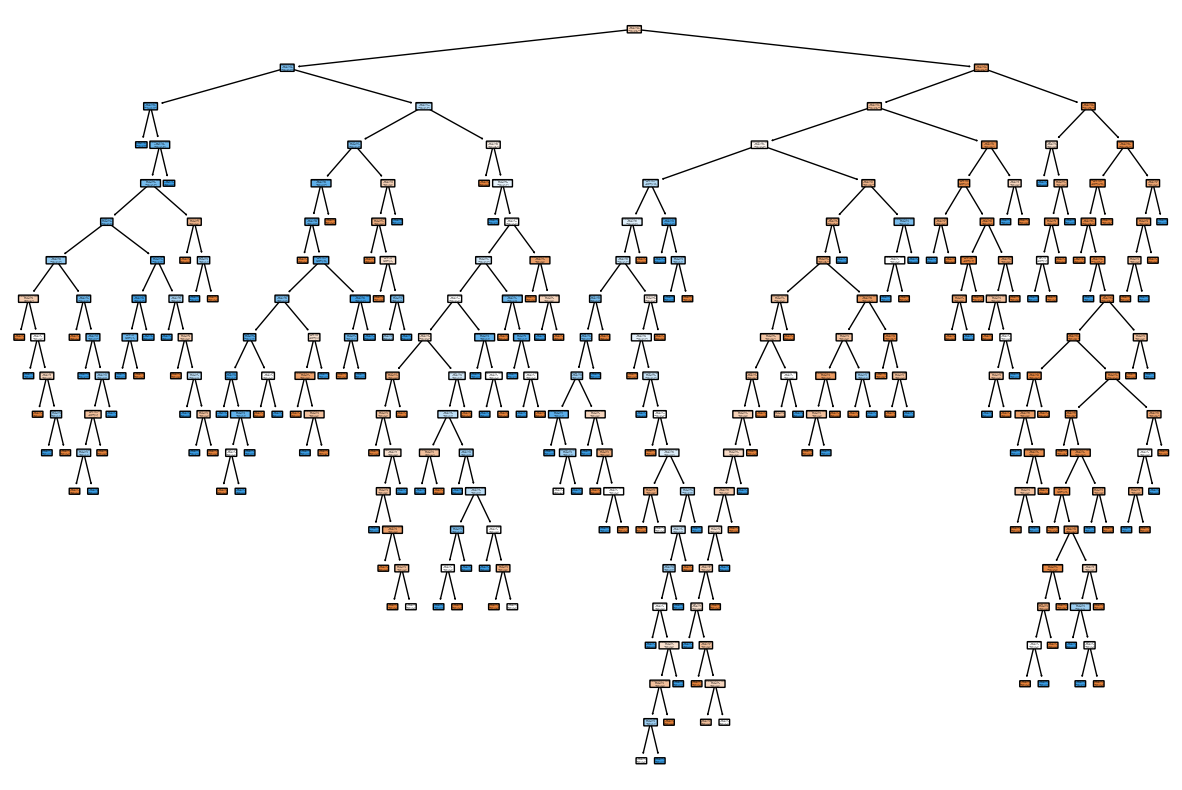

In [48]:
# Plot the decision tree
plt.figure(figsize=(15, 10))
plot_tree(tree_oj, feature_names=predictors, filled=True, rounded=True, class_names=['MM', 'CH'])
plt.show()

Since the tree is so big, we can not interpret it. So we interpret the summary function output.

Variables used in tree construction: SpecialMM variable was used 58 times, the Purchase variable was used 43 times, and so on. This indicates the importance and relevance of each variable in making decisions within the tree.

Number of terminal nodes: There are 172 terminal nodes, which means the tree has 172 distinct prediction classes or categories.

- Predict the response on the test data, and produce a confusion matrix comparing the test labels to the predicted test labels. What is the test error rate?

In [51]:
from sklearn.metrics import confusion_matrix

# Get the predicted values from the fitted tree for the test data
test_predictions = tree_oj.predict(test_set[predictors])

# Calculate the test error rate
test_error_rate = 1 - accuracy_score(test_set['Purchase'], test_predictions)
print('Test Error Rate:', round(test_error_rate,4))

# Create the confusion matrix
confusion_mat = confusion_matrix(test_set['Purchase'], test_predictions)
print('Confusion Matrix:')
print(confusion_mat)

Test Error Rate: 0.2037
Confusion Matrix:
[[129  30]
 [ 25  86]]


- determine the optimal tree size and best score.

In [63]:
from sklearn.model_selection import GridSearchCV

# Define the parameters to search
param_grid = {'max_depth': range(1, 20)}

# Create a decision tree classifier
tree = DecisionTreeClassifier(random_state=42)

# Perform grid search to find the optimal tree size
grid_search = GridSearchCV(tree, param_grid, cv=5, scoring='accuracy')
grid_search.fit(train_set[predictors], train_set['Purchase'])

# Get the best tree size and best score
best_tree_size = grid_search.best_params_['max_depth']
best_score = grid_search.best_score_

print('Optimal Tree Size:', best_tree_size)
print('Best Score:', round(best_score, 4))

Optimal Tree Size: 4
Best Score: 0.8062


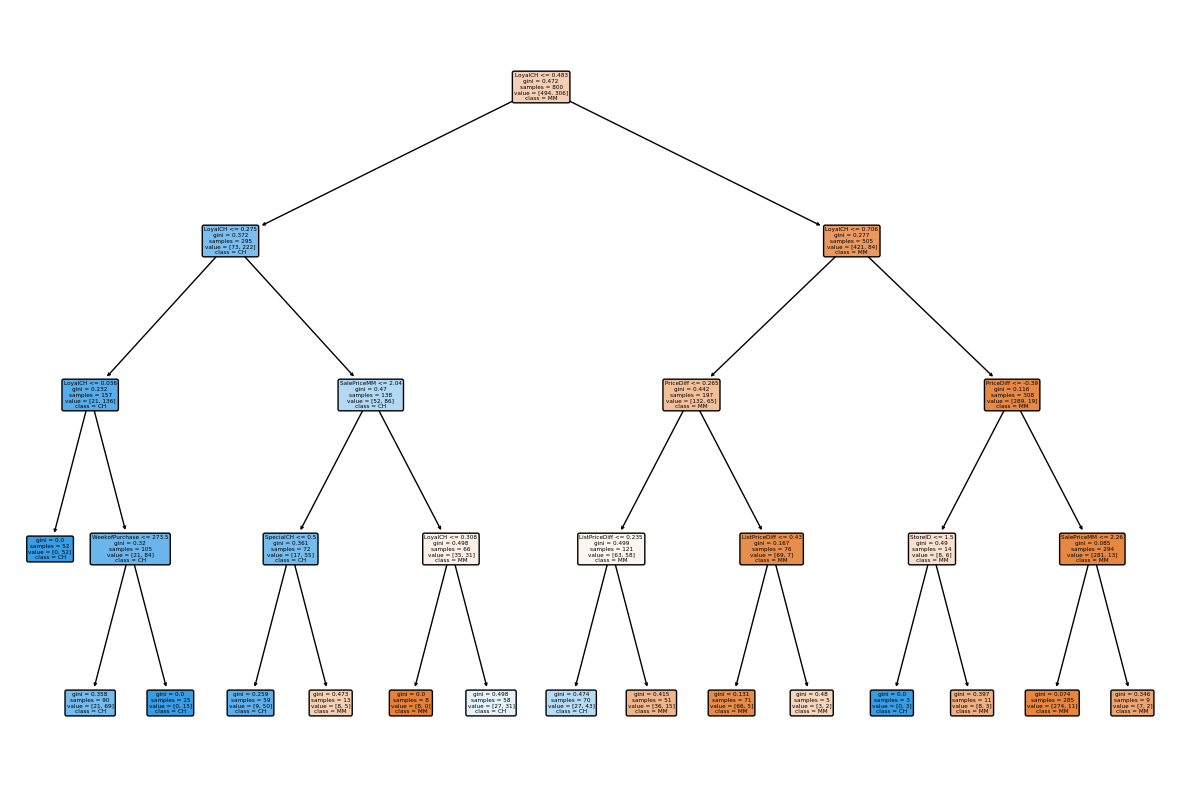

In [64]:
# Fit the decision tree with the optimal tree size
optimal_tree = DecisionTreeClassifier(max_depth=best_tree_size, random_state=42)
optimal_tree.fit(train_set[predictors], train_set['Purchase'])

# Plot the optimal tree
plt.figure(figsize=(15, 10))
plot_tree(optimal_tree, feature_names=predictors, filled=True, rounded=True, class_names=['MM', 'CH'])
plt.show()